# 03 · Extension: SAMME (from scratch)
Report section: *Extension method(s)* + part of *Results*. SAMME on the leakage-safe split, mean +/- std over 3 seeds, plus the convergence curve and the betting-market benchmark. Results saved to `report/results_extension.csv`.

In [1]:
import sys, os; sys.path.insert(0, os.path.abspath('..'))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src.data.pipeline import build_dataset
from src.data.odds import method_market, market_benchmark
from src.extension import SAMMEClassifier
from src.metrics import (accuracy, precision_recall_f1, roc_auc_ovr, log_loss,
                         collapse_winner, collapse_method, summarize_over_seeds)
from src.plotting import (plot_staged_accuracy, plot_decision_regions, plot_confusion_matrix,
                          save_fig, use_report_style, nice_label)
from src.metrics import confusion_matrix
use_report_style()

## 1. Implementation
SAMME lives in `src/extension/samme.py` (validated vs sklearn in `tests/unit/test_samme.py`). The stump caps candidate splits at ~64 quantile thresholds for speed.

## 2. SAMME, seed-averaged (D2 run)
200 stumps per seed (~2 min each after the threshold cap). Scored on the original-corner test, collapsed to winner/method like the baselines.

In [2]:
SEEDS = [0, 1, 2]
acc6, winacc, metacc, ll = ({}, {}, {}, {})
for k in (acc6, winacc, metacc, ll): k['SAMME'] = []
f1m, auc = [], []
keep = {}
for s in SEEDS:
    ds = build_dataset(seed=s)
    Xtr, ytr, Xte, yte = ds.X_train.values, ds.y_train.values, ds.X_test.values, ds.y_test.values
    m = SAMMEClassifier(n_estimators=200).fit(Xtr, ytr)
    proba = m.predict_proba(Xte); pred = m.classes_[proba.argmax(1)]
    acc6['SAMME'].append(accuracy(yte, pred))
    winacc['SAMME'].append(accuracy(collapse_winner(yte), collapse_winner(pred)))
    metacc['SAMME'].append(accuracy(collapse_method(yte), collapse_method(pred)))
    ll['SAMME'].append(log_loss(yte, proba, classes=m.classes_))
    f1m.append(precision_recall_f1(yte, pred, classes=m.classes_)['macro_f1'])
    auc.append(roc_auc_ovr(yte, proba, classes=m.classes_))
    if s == 0: keep = dict(model=m, ds=ds, Xte=Xte, yte=yte)
a_m, a_s = summarize_over_seeds(acc6['SAMME']); w_m, w_s = summarize_over_seeds(winacc['SAMME'])
me_m, _ = summarize_over_seeds(metacc['SAMME']); l_m, _ = summarize_over_seeds(ll['SAMME'])
res = pd.DataFrame([{'model': 'SAMME', 'acc6_mean': a_m, 'acc6_std': a_s, 'winner_mean': w_m,
                     'winner_std': w_s, 'method_mean': me_m,
                     'macro_f1_mean': summarize_over_seeds(f1m)[0],
                     'roc_auc_mean': summarize_over_seeds(auc)[0],
                     'logloss_mean': l_m}]).set_index('model').round(3)
res.to_csv('../report/results_extension.csv'); res

,acc6_mean,acc6_std,winner_mean,winner_std,method_mean,macro_f1_mean,roc_auc_mean,logloss_mean
model,,,,,,,,
SAMME,0.349,0.012,0.633,0.016,0.515,0.297,0.698,1.663


## 3. Hyperparameter analysis (E2)
**(Milica, issue #14)** convergence curve below as a worked example; k and PCA sweeps remain.

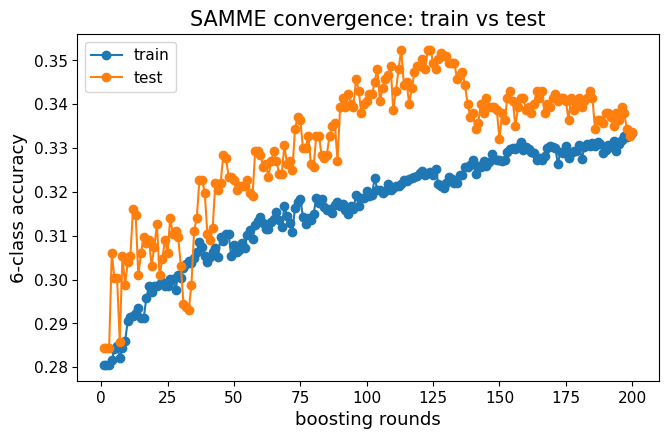

test peak at round 113: acc=0.352
final round 200: train=0.333  test=0.334  (train-test gap -0.000 = mild overfitting past the peak)


In [3]:
# convergence: train vs test accuracy after each boosting round (the overfitting picture)
Xtr0, ytr0 = keep['ds'].X_train.values, keep['ds'].y_train.values
test_scores = keep['model'].staged_score(keep['Xte'], keep['yte'])
train_scores = keep['model'].staged_score(Xtr0, ytr0)
fig, ax = plt.subplots(figsize=(7.5, 4.5))
plot_staged_accuracy(train_scores, ax=ax, label='train')
plot_staged_accuracy(test_scores, ax=ax, label='test')
ax.set_ylabel('6-class accuracy'); ax.set_title('SAMME convergence: train vs test')
save_fig('hyperparam_samme'); plt.show()
peak = int(np.argmax(test_scores)) + 1
print(f'test peak at round {peak}: acc={max(test_scores):.3f}')
print(f'final round 200: train={train_scores[-1]:.3f}  test={test_scores[-1]:.3f}  '
      f'(train-test gap {train_scores[-1]-test_scores[-1]:+.3f} = mild overfitting past the peak)')

**Reading the convergence curve.** Training accuracy keeps climbing as stumps are added, but test accuracy rises only to a peak (around round 110-130) and then drifts slightly down. The widening train-test gap past the peak is textbook mild overfitting; it is *mild* because depth-1 stumps are weak learners, so the ensemble overfits slowly. Practically, ~110-150 rounds is enough and the extra rounds to 200 buy nothing on test. This is the number-of-estimators hyperparameter analysis for SAMME.

### kNN k-sweep (E2)
The second E2 hyperparameter: how many neighbours kNN should use. Small k is noisy (high variance, reacting to single neighbours); 6-class accuracy rises and plateaus around k=15, the value used in the baseline panel, after which extra neighbours add nothing. (Adapted from Milica's sweep, vectorized to run in seconds.)

In [ ]:
# kNN k-sweep (E2, second hyperparameter). One vectorized distance matrix, then read off every
# k - same Euclidean majority-vote rule as KNNClassifier, ~1000x faster than looping its predict.
ds0 = keep['ds']
Xtr0, ytr0 = ds0.X_train.values, ds0.y_train.values
Xte0, yte0 = ds0.X_test.values, ds0.y_test.values
classes_, ytr_enc = np.unique(ytr0, return_inverse=True)
d2 = (Xte0**2).sum(1)[:, None] + (Xtr0**2).sum(1)[None, :] - 2 * Xte0 @ Xtr0.T
ks = [1, 3, 5, 7, 11, 15, 21, 31]; kmax = max(ks)
nn = np.argpartition(d2, kmax, axis=1)[:, :kmax]
row = np.arange(len(Xte0))[:, None]
nn = nn[row, np.argsort(d2[row, nn], axis=1)]          # nearest-first
lab = ytr_enc[nn]
knn_acc = [float((classes_[[np.bincount(r, minlength=len(classes_)).argmax()
                            for r in lab[:, :k]]] == yte0).mean()) for k in ks]
best_k = ks[int(np.argmax(knn_acc))]
pd.DataFrame({'k': ks, 'accuracy': np.round(knn_acc, 3)}).to_csv('../report/results_knn_sweep.csv', index=False)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ks, knn_acc, marker='o'); ax.axvline(best_k, ls=':', c='grey')
ax.set_xlabel('k (neighbours)'); ax.set_ylabel('6-class accuracy')
ax.set_title(f'kNN k-sweep (best k={best_k}, acc={max(knn_acc):.3f})')
plt.tight_layout(); save_fig('hyperparam_knn_k'); plt.show()
print(f'best k = {best_k}; accuracy is noisy at small k and plateaus from k=15')

## 3b. Confusion matrix (6-class)
Where SAMME's errors fall, on the seed-0 split. Predictions concentrate on the common decision classes (Red-DEC, Blue-DEC); knockouts and especially submissions are recovered far less often. (The best baseline's matrix, LDA, is in `02_baselines.ipynb`.)

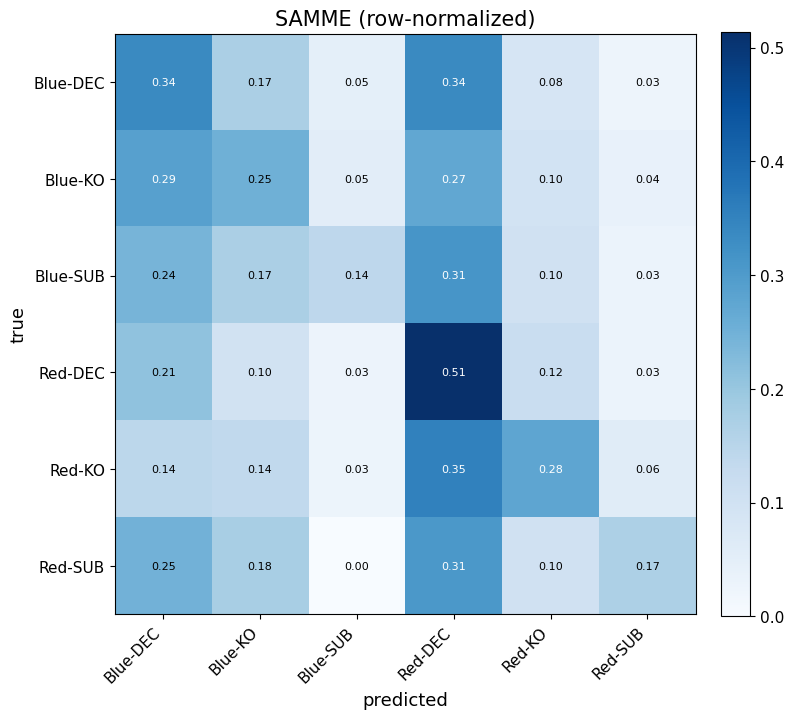

In [4]:
from src.metrics import confusion_matrix
from src.plotting import plot_confusion_matrix
# reuse the seed-0 model kept above (same split the baseline confusion matrix uses)
M, classes = confusion_matrix(keep['yte'], keep['model'].predict(keep['Xte']), classes=keep['model'].classes_)
plot_confusion_matrix(M, classes, normalize=True); plt.title('SAMME (row-normalized)')
save_fig('confusion_matrix_samme'); plt.show()

## 4. Odds benchmark (D4)
SAMME vs the de-vigged per-method market by log-loss / Brier, on test fights with full market coverage.

In [5]:
ds0 = keep['ds']; m = keep['model']
mkt = method_market(ds0.df, classes=m.classes_).loc[ds0.test_index]
res = market_benchmark(ds0.y_test.values, m.predict_proba(ds0.X_test.values), mkt.values, m.classes_)
print(f'covered fights: {res["n_fights"]}')
print(f'log-loss  SAMME={res["log_loss"]["model"]:.3f}  market={res["log_loss"]["market"]:.3f}')
print(f'Brier     SAMME={res["brier"]["model"]:.3f}  market={res["brier"]["market"]:.3f}')
pd.DataFrame([{'metric':'log_loss','SAMME':res['log_loss']['model'],'market':res['log_loss']['market']},
              {'metric':'brier','SAMME':res['brier']['model'],'market':res['brier']['market']}]).to_csv('../report/results_market.csv', index=False)

covered fights: 1099
log-loss  SAMME=1.665  market=1.551
Brier     SAMME=0.793  market=0.749


**Reading the market benchmark.** Scored by log-loss on the fights with full per-method odds, the de-vigged market (1.55) still beats SAMME (1.66), but the gap is small: roughly 12% more probability mass on the true outcome, on average. The market aggregates sharp money and information we do not have, so landing within a point or two of it is the realistic ceiling, not a failure.